In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import re
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Custom modules
sys.path.append('../src')
from signal_analysis.emphasis_detection import (
    EmphasisDetector, 
    RiskClassifier,
    extract_emphasis_features_batch
)
from visualization.plots import (
    plot_emphasis_distribution,
    plot_risk_categories,
    plot_feature_correlation
)

# Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

In [3]:
# Load Processed Data

df = pd.read_csv('../data/processed/consumer_complaints_processed.csv')

print(f"Loaded: {df.shape[0]} complaints")
print(f"Columns: {list(df.columns)}")

# Get complaint text
complaints = df['complaint_clean'].astype(str)

Loaded: 1049446 complaints
Columns: ['Date received', 'year', 'month', 'month_name', 'day_of_week', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Company', 'State', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'complaint_clean', 'char_count', 'word_count', 'sentence_count', 'is_truncated']


In [4]:
# Emphasis Feature Extraction

def count_caps_words(text):
    """Count words in ALL CAPS (minimum 2 letters)"""
    if pd.isna(text):
        return 0
    caps_pattern = r'\b[A-Z]{2,}\b'
    caps_words = re.findall(caps_pattern, str(text))
    return len(caps_words)

def count_exclamations(text):
    """Count exclamation marks"""
    if pd.isna(text):
        return 0
    return str(text).count('!')

def count_questions(text):
    """Count question marks"""
    if pd.isna(text):
        return 0
    return str(text).count('?')

def has_repeated_punctuation(text):
    """Check for repeated punctuation (!!!, ???, ...)"""
    if pd.isna(text):
        return False
    pattern = r'([!?.])\1{1,}'  # Same punctuation 2+ times
    return bool(re.search(pattern, str(text)))

def count_urgent_keywords(text):
    """Count urgent/escalation keywords"""
    if pd.isna(text):
        return 0
    
    urgent_words = [
        'fraud', 'stolen', 'unauthorized', 'scam', 'theft',
        'emergency', 'immediately', 'urgent', 'critical',
        'lawyer', 'attorney', 'sue', 'lawsuit', 'legal action',
        'complaint', 'dispute', 'unacceptable', 'terrible',
        'harassment', 'threatening', 'illegal', 'criminal'
    ]
    
    text_lower = str(text).lower()
    count = sum(1 for word in urgent_words if word in text_lower)
    return count

def calculate_emphasis_score(row):
    """
    Calculate composite emphasis score (0-1)
    Weighted combination of all features
    """
    # Normalize each component (cap at reasonable max)
    caps_score = min(row['caps_words'] / 10, 1.0)          # Max 10 CAPS words
    exclaim_score = min(row['exclamations'] / 5, 1.0)       # Max 5 exclamations
    question_score = min(row['questions'] / 5, 1.0)         # Max 5 questions
    repeat_score = 1.0 if row['repeated_punct'] else 0.0
    urgent_score = min(row['urgent_keywords'] / 3, 1.0)     # Max 3 urgent words
    
    # Weighted combination
    emphasis_score = (
        0.25 * caps_score +           # 25% weight
        0.20 * exclaim_score +        # 20% weight
        0.10 * question_score +       # 10% weight
        0.15 * repeat_score +         # 15% weight
        0.30 * urgent_score           # 30% weight - most important
    )
    
    return emphasis_score

# Apply feature extraction

df['caps_words'] = df['complaint_clean'].apply(count_caps_words)
df['exclamations'] = df['complaint_clean'].apply(count_exclamations)
df['questions'] = df['complaint_clean'].apply(count_questions)
df['repeated_punct'] = df['complaint_clean'].apply(has_repeated_punctuation)
df['urgent_keywords'] = df['complaint_clean'].apply(count_urgent_keywords)

# Calculate emphasis score
df['emphasis_score'] = df.apply(calculate_emphasis_score, axis=1)


In [5]:
# Feature Statistics

print("EMPHASIS FEATURE STATISTICS")

feature_cols = ['caps_words', 'exclamations', 'questions', 
                'urgent_keywords', 'emphasis_score']

print("\n Descriptive Statistics:")
print(df[feature_cols].describe())

print("\n Feature Value Ranges:")
for col in feature_cols:
    min_val = df[col].min()
    max_val = df[col].max()
    mean_val = df[col].mean()
    median_val = df[col].median()
    print(f"{col:.<30} Min: {min_val:>6.2f}  Max: {max_val:>6.2f}  Mean: {mean_val:>6.2f}  Median: {median_val:>6.2f}")

print(f"\n Repeated Punctuation:")
print(f"   Has repeated punctuation: {df['repeated_punct'].sum()} ({df['repeated_punct'].mean()*100:.1f}%)")
print(f"   No repeated punctuation:  {(~df['repeated_punct']).sum()} ({(~df['repeated_punct']).mean()*100:.1f}%)")

EMPHASIS FEATURE STATISTICS

 Descriptive Statistics:
         caps_words  exclamations     questions  urgent_keywords  \
count  1.049446e+06  1.049446e+06  1.049446e+06     1.049446e+06   
mean   5.176489e+00  1.140964e-01  4.931268e-02     1.694069e+00   
std    1.811100e+01  8.246140e-01  5.323768e-01     1.674054e+00   
min    0.000000e+00  0.000000e+00  0.000000e+00     0.000000e+00   
25%    0.000000e+00  0.000000e+00  0.000000e+00     0.000000e+00   
50%    1.000000e+00  0.000000e+00  0.000000e+00     1.000000e+00   
75%    4.000000e+00  0.000000e+00  0.000000e+00     3.000000e+00   
max    2.103000e+03  1.230000e+02  1.180000e+02     1.400000e+01   

       emphasis_score  
count    1.049446e+06  
mean     2.128873e-01  
std      1.671788e-01  
min      0.000000e+00  
25%      1.000000e-01  
50%      2.000000e-01  
75%      3.500000e-01  
max      1.000000e+00  

 Feature Value Ranges:
caps_words.................... Min:   0.00  Max: 2103.00  Mean:   5.18  Median:   1.00
exclam

In [6]:
# Risk Classification

def classify_risk(emphasis_score):
    """Classify risk level based on emphasis score"""
    if emphasis_score >= 0.6:
        return 'High'
    elif emphasis_score >= 0.3:
        return 'Medium'
    else:
        return 'Low'

# Apply classification
df['risk_level'] = df['emphasis_score'].apply(classify_risk)
df['is_high_risk'] = df['risk_level'] == 'High'

# Count by risk level
risk_counts = df['risk_level'].value_counts()

print("\n" + "="*80)
print("RISK CLASSIFICATION RESULTS")
print("="*80)

print(f"\n Risk Level Distribution:")
for level in ['High', 'Medium', 'Low']:
    if level in risk_counts.index:
        count = risk_counts[level]
        percentage = (count / len(df)) * 100
        print(f"   {level:.<20} {count:>6} complaints ({percentage:>5.2f}%)")

print(f"\n High-Risk Complaints: {df['is_high_risk'].sum()}")
print(f"   Percentage of total: {(df['is_high_risk'].sum() / len(df) * 100):.2f}%")


RISK CLASSIFICATION RESULTS

 Risk Level Distribution:
   High................   8690 complaints ( 0.83%)
   Medium.............. 357265 complaints (34.04%)
   Low................. 683491 complaints (65.13%)

 High-Risk Complaints: 8690
   Percentage of total: 0.83%


In [7]:
# High-Risk Complaint Analysis

# Filter high-risk complaints
high_risk = df[df['risk_level'] == 'High'].copy()

print("HIGH-RISK COMPLAINT ANALYSIS")

print(f"\nTotal high-risk complaints: {len(high_risk)}")

# Average features for high-risk vs. all
print("\n Average Features Comparison:")
print(f"{'Feature':<25} {'High-Risk':>12} {'All Complaints':>15} {'Difference':>12}")
print("-"*80)

for col in ['caps_words', 'exclamations', 'questions', 'urgent_keywords']:
    high_risk_avg = high_risk[col].mean()
    all_avg = df[col].mean()
    diff = high_risk_avg - all_avg
    print(f"{col:<25} {high_risk_avg:>12.2f} {all_avg:>15.2f} {diff:>12.2f}")

# Product breakdown for high-risk
print("\n High-Risk Complaints by Product:")
high_risk_products = high_risk['Product'].value_counts().head(10)
for product, count in high_risk_products.items():
    pct = (count / len(high_risk)) * 100
    print(f"   {product:.<50} {count:>4} ({pct:>5.1f}%)")

# Show sample high-risk complaints
print("\n Sample High-Risk Complaints:")

for i, (idx, row) in enumerate(high_risk.nlargest(3, 'emphasis_score').iterrows(), 1):
    print(f"\nSample {i}:")
    print(f"Emphasis Score: {row['emphasis_score']:.3f}")
    print(f"CAPS words: {row['caps_words']}, Exclamations: {row['exclamations']}, Urgent keywords: {row['urgent_keywords']}")
    print(f"Product: {row['Product']}")
    print(f"Text: {row['complaint_clean'][:300]}...")
    print("-"*80)

HIGH-RISK COMPLAINT ANALYSIS

Total high-risk complaints: 8690

 Average Features Comparison:
Feature                      High-Risk  All Complaints   Difference
--------------------------------------------------------------------------------
caps_words                       37.60            5.18        32.43
exclamations                      3.48            0.11         3.36
questions                         1.36            0.05         1.31
urgent_keywords                   4.08            1.69         2.38

 High-Risk Complaints by Product:
   Credit Reporting Or Other Personal Consumer Reports 6199 ( 71.3%)
   Debt Collection...................................  647 (  7.4%)
   Checking Or Savings Account.......................  612 (  7.0%)
   Credit Card.......................................  473 (  5.4%)
   Mortgage..........................................  240 (  2.8%)
   Money Transfer, Virtual Currency, Or Money Service  216 (  2.5%)
   Vehicle Loan Or Lease.................

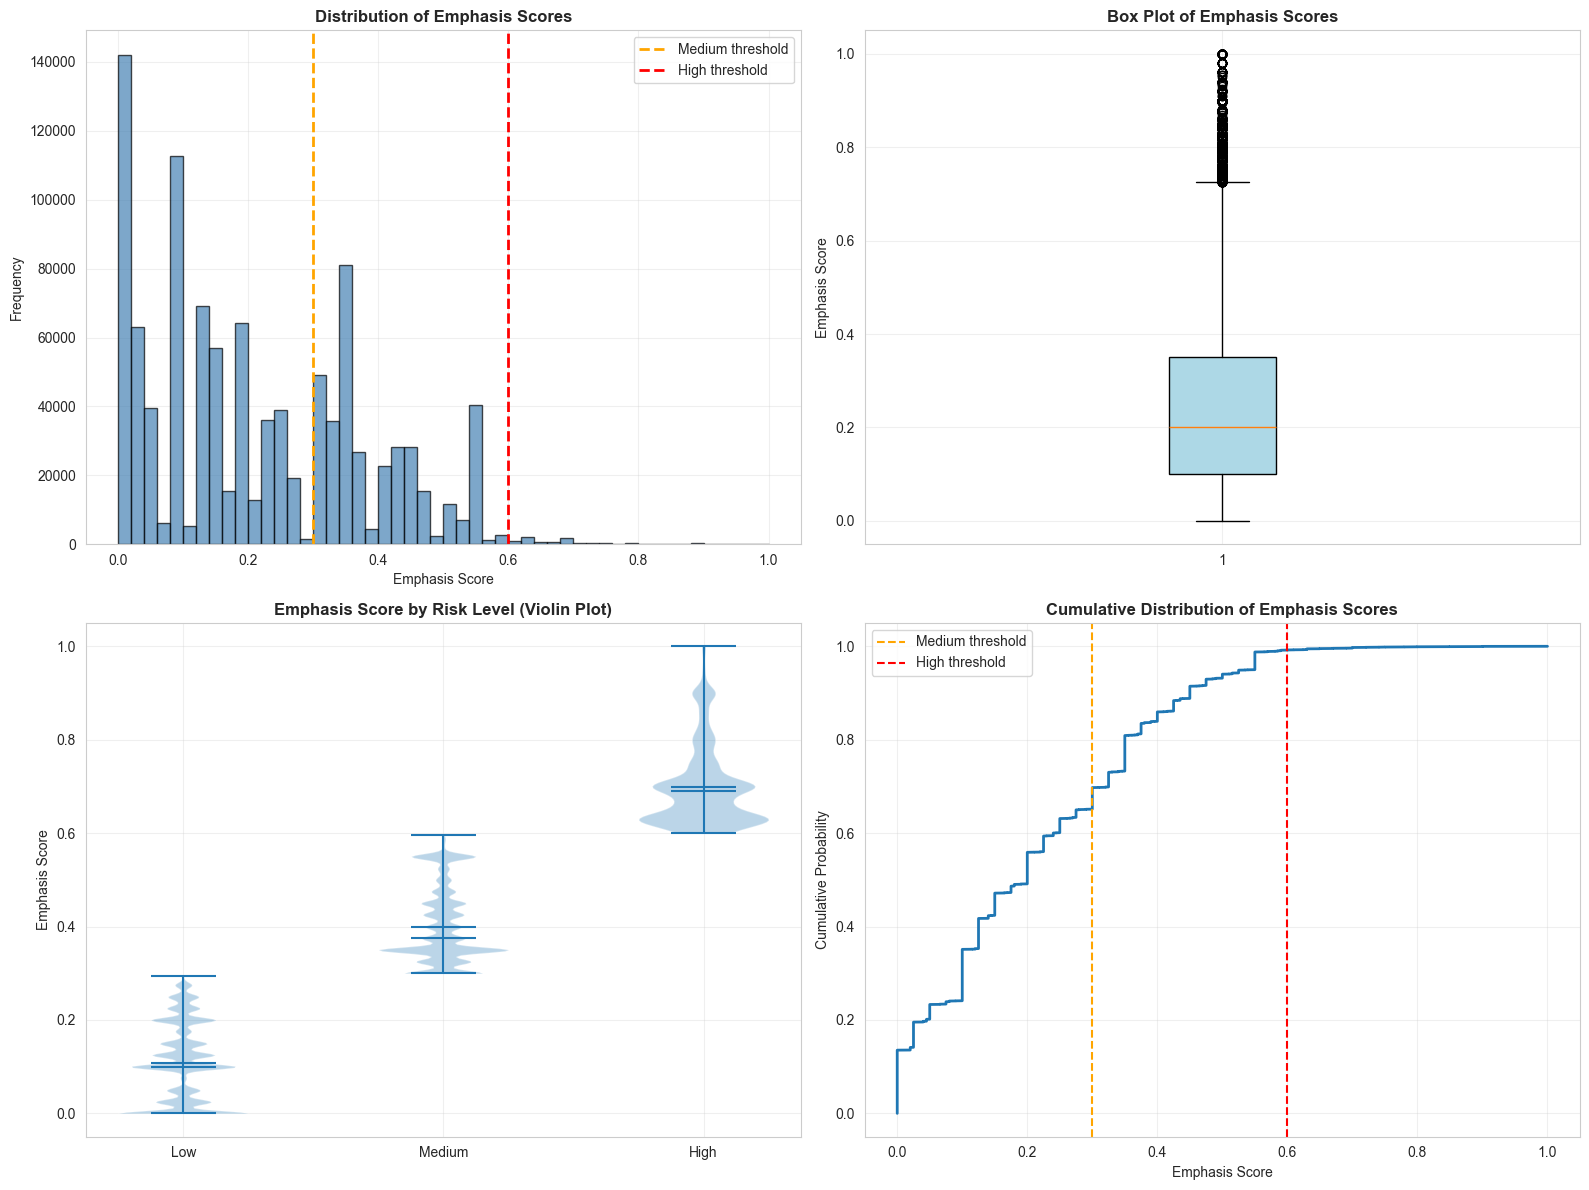

In [8]:
# VISUALIZATION 1: Emphasis Score Distribution

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram
axes[0, 0].hist(df['emphasis_score'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(0.3, color='orange', linestyle='--', linewidth=2, label='Medium threshold')
axes[0, 0].axvline(0.6, color='red', linestyle='--', linewidth=2, label='High threshold')
axes[0, 0].set_xlabel('Emphasis Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Emphasis Scores', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Box plot
bp = axes[0, 1].boxplot(df['emphasis_score'], vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
axes[0, 1].set_ylabel('Emphasis Score')
axes[0, 1].set_title('Box Plot of Emphasis Scores', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Emphasis score by risk level
risk_order = ['Low', 'Medium', 'High']
df_plot = df[df['risk_level'].isin(risk_order)]
axes[1, 0].violinplot([df_plot[df_plot['risk_level']==level]['emphasis_score'].values 
                        for level in risk_order],
                       positions=range(len(risk_order)),
                       showmeans=True,
                       showmedians=True)
axes[1, 0].set_xticks(range(len(risk_order)))
axes[1, 0].set_xticklabels(risk_order)
axes[1, 0].set_ylabel('Emphasis Score')
axes[1, 0].set_title('Emphasis Score by Risk Level (Violin Plot)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# CDF (Cumulative Distribution)
sorted_scores = np.sort(df['emphasis_score'])
cdf = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
axes[1, 1].plot(sorted_scores, cdf, linewidth=2)
axes[1, 1].axvline(0.3, color='orange', linestyle='--', label='Medium threshold')
axes[1, 1].axvline(0.6, color='red', linestyle='--', label='High threshold')
axes[1, 1].set_xlabel('Emphasis Score')
axes[1, 1].set_ylabel('Cumulative Probability')
axes[1, 1].set_title('Cumulative Distribution of Emphasis Scores', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/emphasis_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

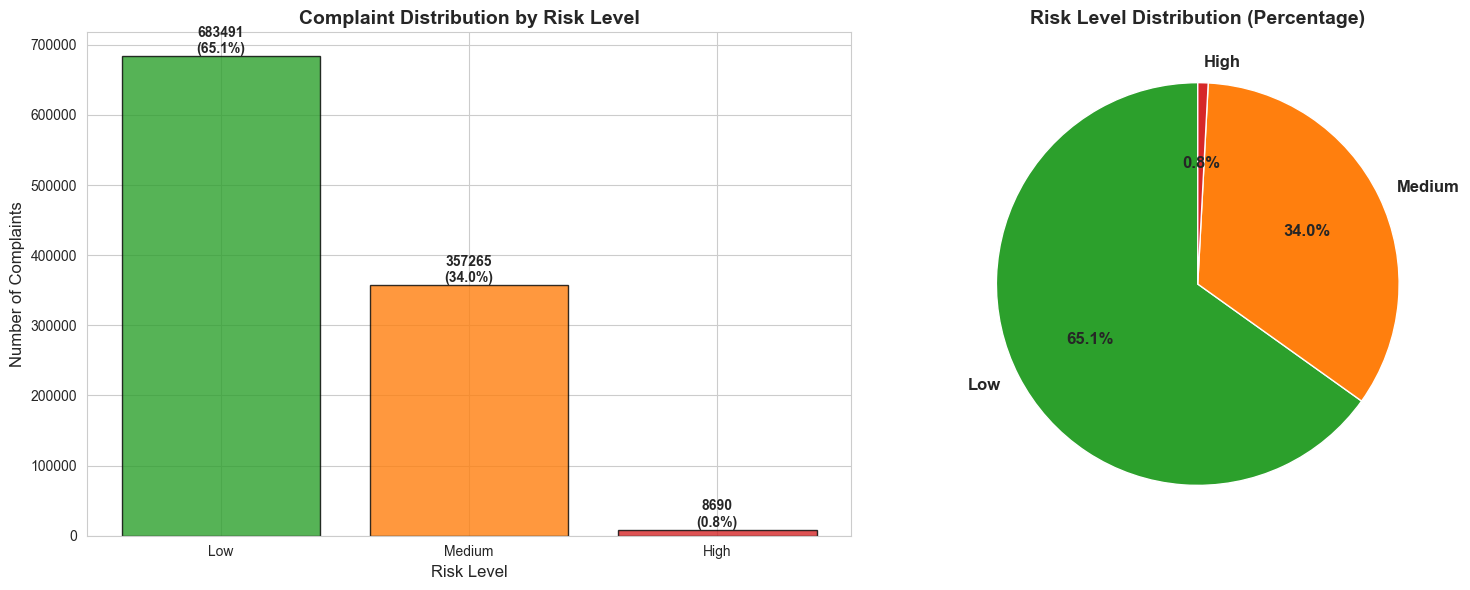

In [9]:
# VISUALIZATION 2: Risk Categories

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
colors = {'High': '#d62728', 'Medium': '#ff7f0e', 'Low': '#2ca02c'}
risk_counts = df['risk_level'].value_counts()

bars = axes[0].bar(risk_counts.index, risk_counts.values, 
                   color=[colors[level] for level in risk_counts.index],
                   alpha=0.8, edgecolor='black')
axes[0].set_xlabel('Risk Level', fontsize=12)
axes[0].set_ylabel('Number of Complaints', fontsize=12)
axes[0].set_title('Complaint Distribution by Risk Level', fontsize=14, fontweight='bold')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}\n({height/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%',
           colors=[colors[level] for level in risk_counts.index],
           startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Risk Level Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/risk_category_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()

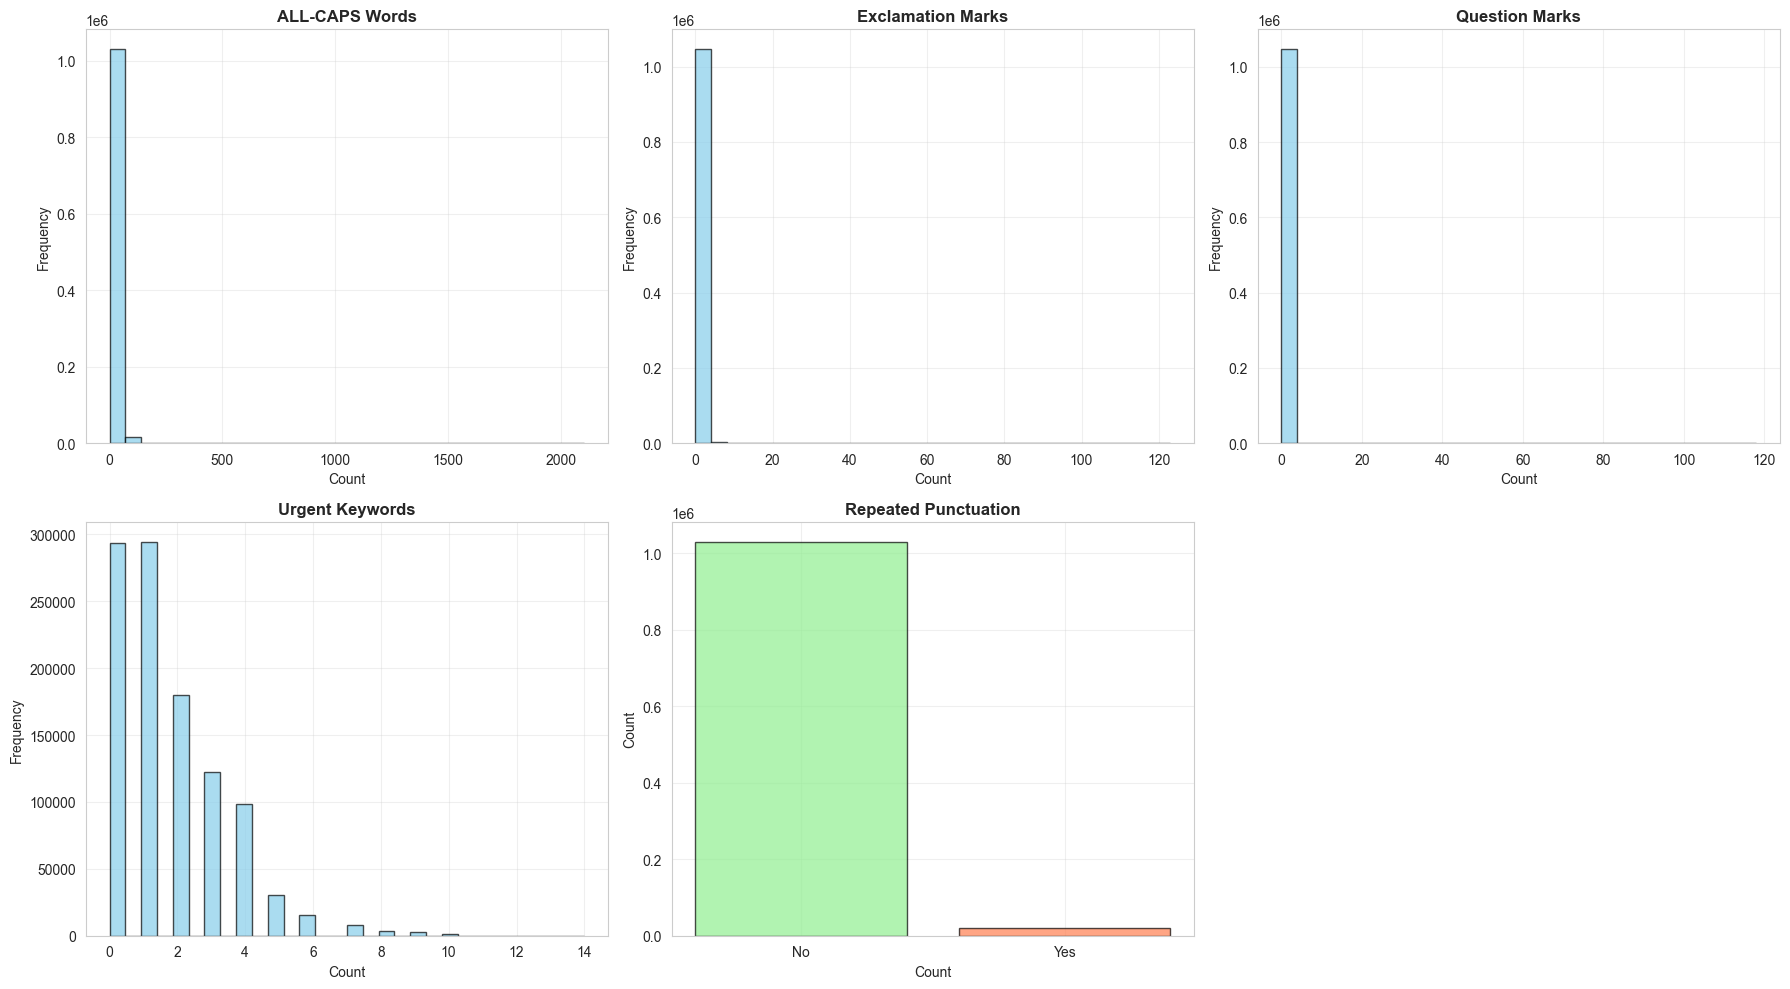

In [10]:
# VISUALIZATION 3: Individual Features

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

features = ['caps_words', 'exclamations', 'questions', 
            'urgent_keywords', 'repeated_punct']
titles = ['ALL-CAPS Words', 'Exclamation Marks', 'Question Marks',
         'Urgent Keywords', 'Repeated Punctuation']

for idx, (feature, title) in enumerate(zip(features, titles)):
    if feature == 'repeated_punct':
        # Binary feature - bar chart
        counts = df[feature].value_counts()
        axes[idx].bar(['No', 'Yes'], [counts.get(False, 0), counts.get(True, 0)],
                     color=['lightgreen', 'coral'], alpha=0.7, edgecolor='black')
        axes[idx].set_ylabel('Count')
    else:
        # Continuous features - histogram
        axes[idx].hist(df[feature], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
        axes[idx].set_ylabel('Frequency')
    
    axes[idx].set_title(title, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Count')
    axes[idx].grid(True, alpha=0.3)

# Remove empty subplot
axes[5].axis('off')

plt.tight_layout()
plt.savefig('../outputs/figures/feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

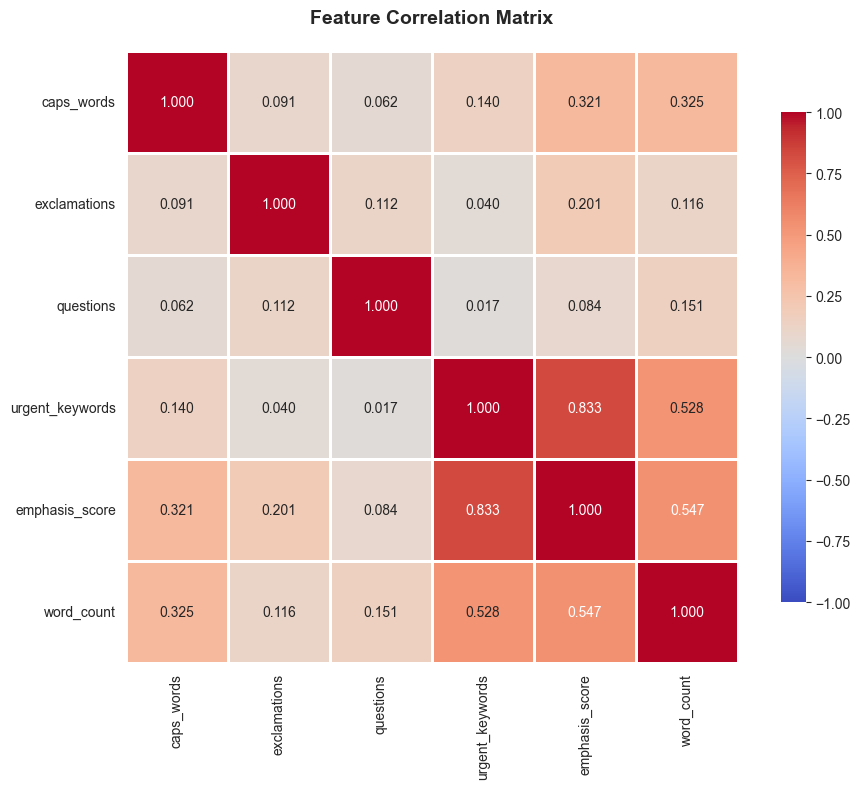


 Correlation Insights:

Strongest Positive Correlations:
   caps_words ↔ emphasis_score: 0.321
   caps_words ↔ word_count: 0.325
   urgent_keywords ↔ emphasis_score: 0.833
   urgent_keywords ↔ word_count: 0.528
   emphasis_score ↔ word_count: 0.547


In [11]:
# VISUALIZATION 4: Feature Correlation

# Select numerical features
feature_cols = ['caps_words', 'exclamations', 'questions', 
                'urgent_keywords', 'emphasis_score', 'word_count']

# Calculate correlation matrix
corr_matrix = df[feature_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../outputs/figures/feature_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

# Print correlation insights
print("\n Correlation Insights:")
print("\nStrongest Positive Correlations:")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if corr_val > 0.3:
            print(f"   {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: {corr_val:.3f}")

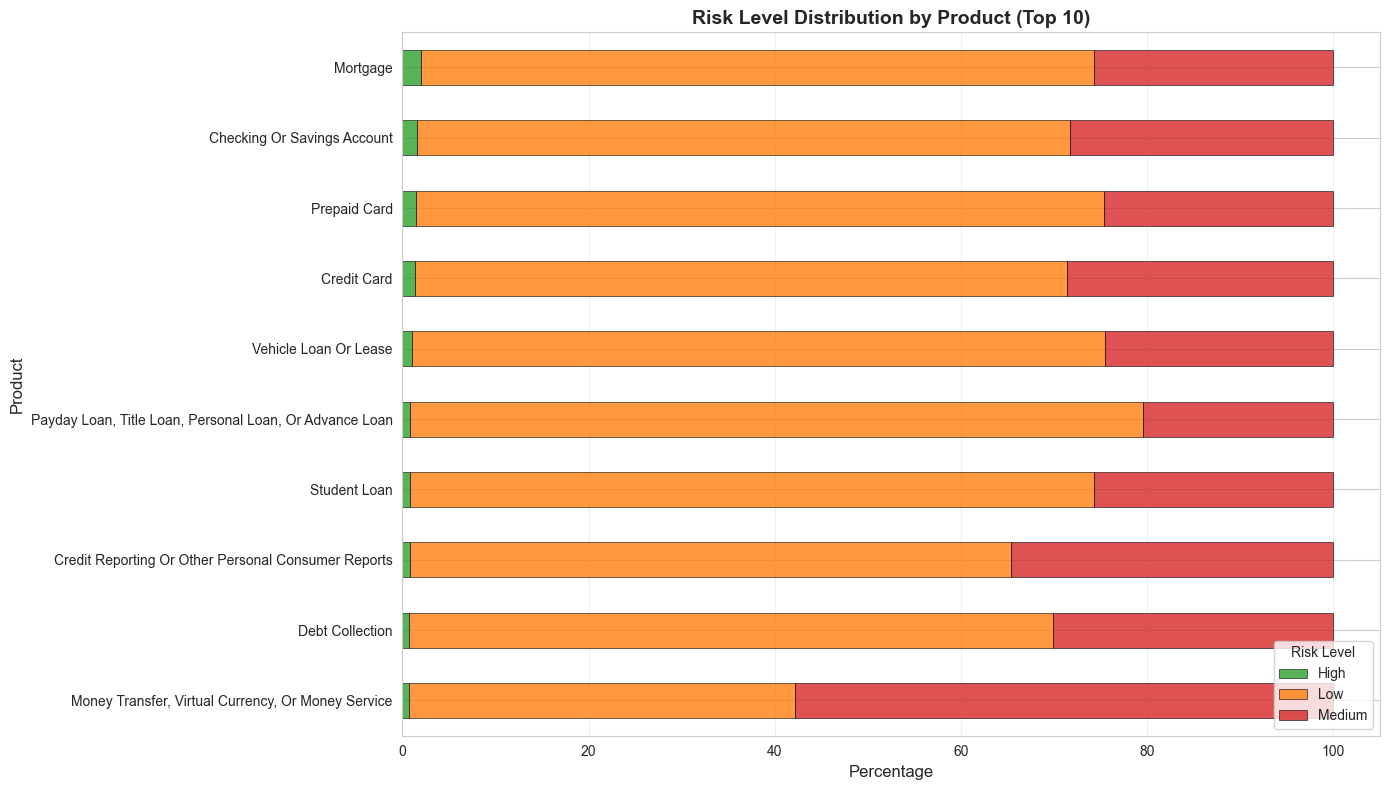

In [12]:
# VISUALIZATION 5: Risk by Product

# Get top 10 products
top_products = df['Product'].value_counts().head(10).index
df_top = df[df['Product'].isin(top_products)]

# Create pivot table
risk_by_product = pd.crosstab(df_top['Product'], df_top['risk_level'], normalize='index') * 100

# Sort by high-risk percentage
if 'High' in risk_by_product.columns:
    risk_by_product = risk_by_product.sort_values('High', ascending=True)

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(14, 8))

risk_by_product.plot(kind='barh', stacked=True, ax=ax,
                     color=['#2ca02c', '#ff7f0e', '#d62728'],
                     alpha=0.8, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Percentage', fontsize=12)
ax.set_ylabel('Product', fontsize=12)
ax.set_title('Risk Level Distribution by Product (Top 10)', fontsize=14, fontweight='bold')
ax.legend(title='Risk Level', loc='lower right')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../outputs/figures/risk_by_product.png', dpi=300, bbox_inches='tight')
plt.show()